### Data describtion and preperation**

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()
amazon = pd.read_csv("C:/Users/lilpo/OneDrive/Рабочий стол/Business  Analytics Final Project Lilit/amazon.csv")

In [11]:
amazon.head()
amazon.info()
amazon = amazon.dropna()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

In [13]:
amazon.describe(include="all")

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
count,1463,1463,1463,1463,1463,1463,1463,1463,1463,1463,1463,1463,1463,1463,1463,1463
unique,1349,1335,211,550,449,92,28,1143,1291,1192,1192,1192,1192,1210,1410,1463
top,B07JW9H4J1,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",Computers&Accessories|Accessories&Peripherals|...,₹199,₹999,50%,4.1,"9,378",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AHIKJUDTVJ4T6DV6IUGFYZ5LXMPA,AE55KTFVNXYFD5FPY...","$@|\|TO$|-|,Sethu madhav,Akash Thakur,Burger P...","R3F4T5TRYPTMIG,R3DQIEC603E7AY,R1O4Z15FD40PV5,R...","Worked on iPhone 7 and didn’t work on XR,Good ...","I am not big on camera usage, personally. I wa...",https://m.media-amazon.com/images/I/413sCRKobN...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
freq,3,5,231,52,118,56,244,9,6,10,10,10,10,8,3,1


In [15]:
amazon["actual_price"] = amazon["actual_price"].replace('[₹,]', '', regex=True).astype(float)
amazon["discounted_price"] = amazon["discounted_price"].replace('[₹,]', '', regex=True).astype(float)
amazon["discount_percentage"] = (
    amazon["discount_percentage"]
    .astype(str)                 
    .str.replace("%", "", regex=False)
    .str.replace(" ", "")        
    .astype(float)               
)

In [17]:
import numpy as np

def clean_numeric(col):
    return (
        amazon[col]
        .astype(str)
        .str.replace("[^0-9.]", "", regex=True)   # keep only digits and dot
        .replace("", np.nan)                      # convert empty strings to NaN
        .astype(float)
    )

In [19]:
amazon["discounted_price"] = clean_numeric("discounted_price").astype(int)
amazon["actual_price"] = clean_numeric("actual_price").astype(int)
amazon["discount_percentage"] = clean_numeric("discount_percentage").astype(int)
amazon["rating"] = clean_numeric("rating")  # keep as float (ratings may be decimals)
amazon["rating_count"] = clean_numeric("rating_count").fillna(0).astype(int)

In [21]:
amazon = amazon.drop(columns=["review_content", "about_product", "user_name", "review_title", "img_link", "product_link"])

In [23]:
amazon.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,user_id,review_id
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399,1099,64,4.2,24269,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K..."
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199,349,43,4.0,43994,"AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY..."
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199,1899,90,3.9,7928,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2..."
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329,699,53,4.2,94363,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1..."
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154,399,61,4.2,16905,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R..."


Since the dataset was manually filled, the category column contains overly detailed and inconsistent labels. To improve analysis quality and ensure comparability across products, I decided to standardize and group all categories into nine broader, well-defined category groups.

In [25]:
amazon["category"] = amazon["category"].astype(str).str.split("|").str[0]
amazon.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,user_id,review_id
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories,399,1099,64,4.2,24269,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K..."
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories,199,349,43,4.0,43994,"AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY..."
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories,199,1899,90,3.9,7928,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2..."
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories,329,699,53,4.2,94363,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1..."
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories,154,399,61,4.2,16905,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R..."


**KPI**

KPI COLUMNS

Three key performance indicators were derived from the cleaned dataset: **discount depth**, measuring the relative magnitude of price reductions; **rating-to-price ratio**, capturing perceived customer value relative to cost; and a **low-rating flag**, identifying products with poor customer satisfaction outcomes (ratings of 2 or below).

In [27]:
amazon["discount_depth"] = (amazon["actual_price"] - amazon["discounted_price"]) / amazon["actual_price"]
amazon["rating_price_ratio"] = amazon["rating"] / amazon["discounted_price"]
amazon["low_rating_flag"] = amazon["rating"] <= 2

Averaged important variables for each category (KPI s)

In [29]:
kpi_discount = amazon.groupby("category")["discount_percentage"].mean().reset_index().round(2)
kpi_discount

,category,discount_percentage
0,Car&Motorbike,42.00
1,Computers&Accessories,53.92
2,Electronics,50.83
3,Health&PersonalCare,53.00
4,Home&Kitchen,40.12
5,HomeImprovement,57.50
6,MusicalInstruments,46.00
7,OfficeProducts,12.35
8,Toys&Games,0.00


In [31]:
kpi_rating = amazon.groupby("category")["rating"].mean().reset_index().round(2)
kpi_rating

,category,rating
0,Car&Motorbike,3.80
1,Computers&Accessories,4.16
2,Electronics,4.08
3,Health&PersonalCare,4.00
4,Home&Kitchen,4.04
5,HomeImprovement,4.25
6,MusicalInstruments,3.90
7,OfficeProducts,4.31
8,Toys&Games,4.30


In [33]:
kpi_reviews = amazon.groupby("category")["rating_count"].sum().reset_index()
kpi_reviews

,category,rating_count
0,Car&Motorbike,1118
1,Computers&Accessories,7728689
2,Electronics,15778848
3,Health&PersonalCare,3663
4,Home&Kitchen,2991069
5,HomeImprovement,8566
6,MusicalInstruments,88882
7,OfficeProducts,149675
8,Toys&Games,15867


In [35]:
correlation = amazon["discount_percentage"].corr(amazon["rating_count"])
correlation

0.011690974046132861

The computed correlation between discount percentage and review count is approximately 0.01, indicating an extremely weak positive relationship, and suggesting that higher discounts are not meaningfully associated with increased customer engagement

**The following visualizations provide a brief overview of the data and its main characteristics**


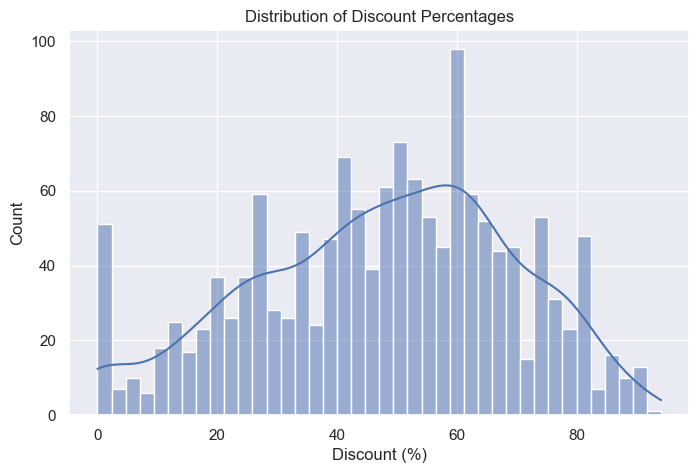

In [37]:
plt.figure(figsize=(8,5))
sns.histplot(amazon["discount_percentage"], bins=40, kde=True)
plt.title("Distribution of Discount Percentages")
plt.xlabel("Discount (%)")
plt.ylabel("Count")
plt.show()

This histogram shows how discounts are distributed across all products, with most discounts concentrated in the mid-range rather than at very low or very high levels. The smooth density curve suggests that moderate discounts are more common than extreme promotions.

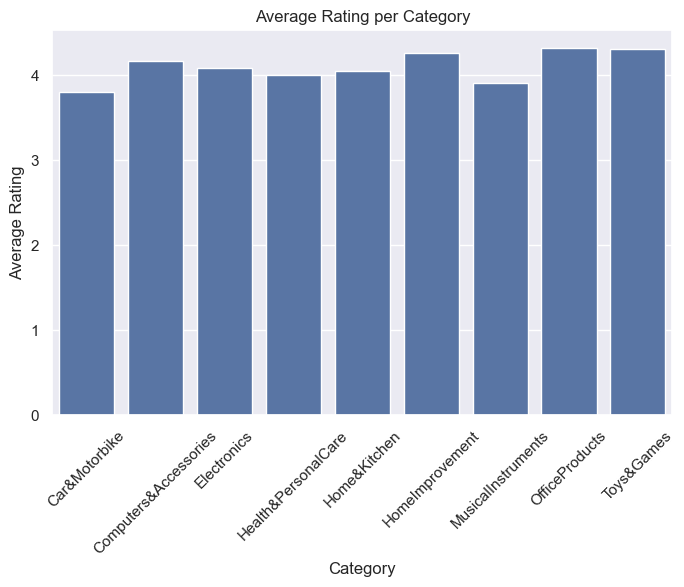

In [39]:
plt.figure(figsize=(8,5))
sns.barplot(data=kpi_rating, x="category", y="rating")
plt.title("Average Rating per Category")
plt.xlabel("Category")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()

This bar chart compares the average customer rating across product categories and shows that ratings are generally high and fairly consistent. Differences between categories are relatively small, indicating similar customer satisfaction levels across most product types.

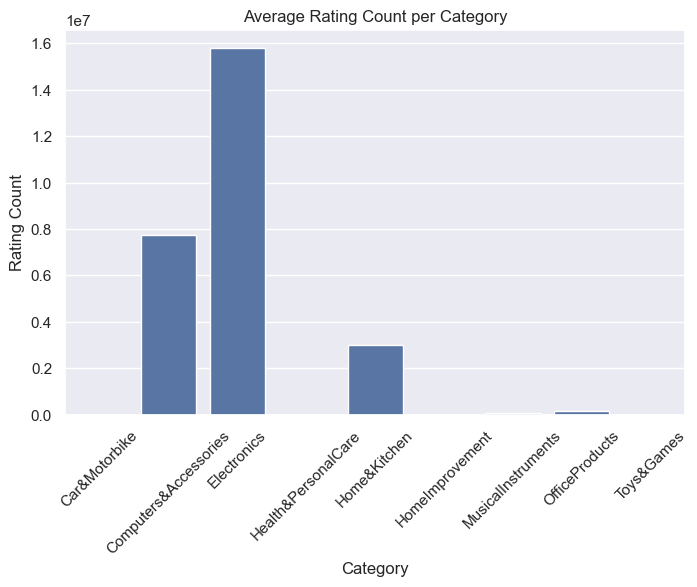

In [41]:
plt.figure(figsize=(8,5))
sns.barplot(data=kpi_reviews, x="category", y="rating_count")
plt.title("Average Rating Count per Category")
plt.xlabel("Category")
plt.ylabel("Rating Count")
plt.xticks(rotation=45)
plt.show()

This visualization shows large differences in average review volume across categories, highlighting which categories are most popular and receive the most customer attention. Electronics and Computers & Accessories dominate in review counts, while several other categories have substantially lower engagement.

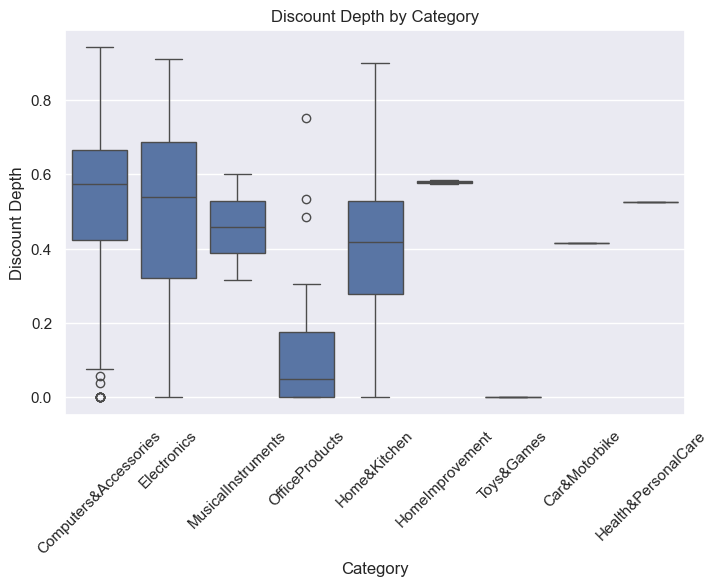

In [43]:
plt.figure(figsize=(8,5))
sns.boxplot(data=amazon, x="category", y="discount_depth")
plt.title("Discount Depth by Category")
plt.xlabel("Category")
plt.ylabel("Discount Depth")
plt.xticks(rotation=45)
plt.show()

This chart shows how discount levels vary across categories and where each category contributes most to the overall discount distribution. It highlights that mid-range discounts are common across multiple categories, while extreme discounts are less frequent.

In [45]:
amazon.to_csv("amazon_clean_final.csv", index=False)

### Analytical model with interpretation**

Linear regression

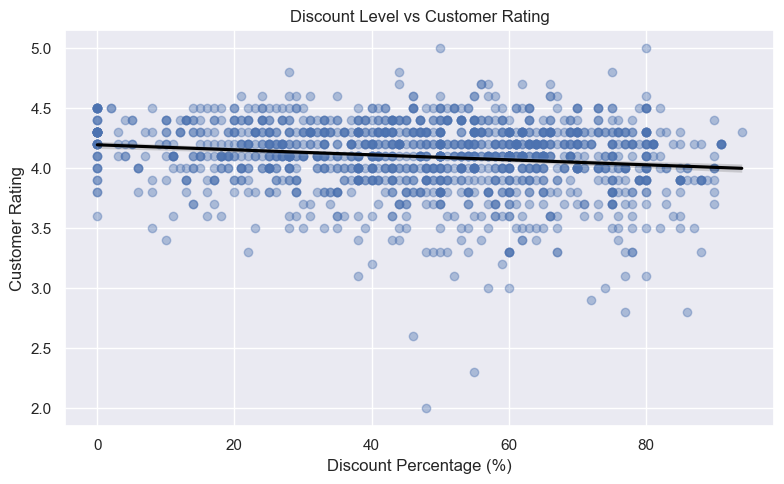

In [47]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=amazon,
    x="discount_percentage",
    y="rating",
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "black"}
)

plt.title("Discount Level vs Customer Rating")
plt.xlabel("Discount Percentage (%)")
plt.ylabel("Customer Rating")
plt.tight_layout()
plt.show()

Although the regression line appears visually stable with points closely clustered around it, the relationship between discount level and customer rating is weak because ratings change very little across a wide range of discount values. This indicates that discounts do not meaningfully influence customer satisfaction, even though most products maintain consistently high ratings.

**K-Means model and interpretation**

In [61]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
features = amazon[[
    "discount_percentage",
    "discount_depth",
    "rating",
    "rating_count"
]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_clean)

k_means = KMeans(n_clusters=3, random_state=42)
                 
features_clean = features.dropna()
labels = k_means.fit_predict(X_scaled)

In [63]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_clean)

In [65]:
from sklearn.model_selection import train_test_split
X_train, X_temp = train_test_split(
    X_scaled, test_size=0.3, random_state=42)
X_val, X_test = train_test_split(
    X_temp, test_size=0.5, random_state=42)

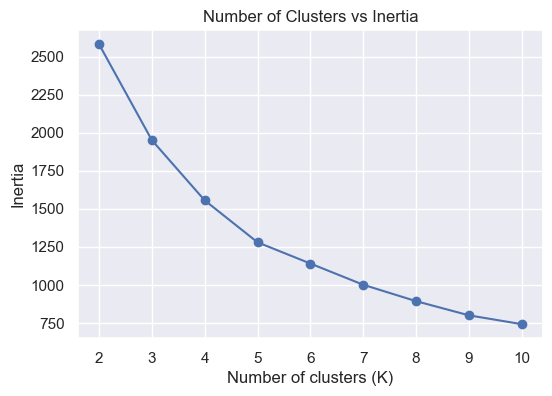

In [67]:
import matplotlib.pyplot as plt

options = range(2, 11)
inertias = []

for n_clusters in options:
    model = KMeans(n_clusters=n_clusters, random_state=42)
    model.fit(X_train)
    inertias.append(model.inertia_)

plt.figure(figsize=(6,4))
plt.title("Number of Clusters vs Inertia")
plt.plot(options, inertias, '-o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.show()

This plot shows how the clustering error (inertia) decreases as the number of clusters increases. The curve drops sharply up to K = 3 and then flattens, indicating diminishing returns from adding more clusters. This suggests that three clusters provide a good balance between simplicity and explanatory power for grouping products.

In [69]:
from sklearn.metrics import silhouette_score

k_means = KMeans(n_clusters=3, n_init=10, random_state=42)

labels_train = k_means.fit_predict(X_train)
train_kmeans_avg = silhouette_score(X_train, labels_train)

labels_validation = k_means.predict(X_val)
val_kmeans_avg = silhouette_score(X_val, labels_validation)

labels_test = k_means.predict(X_test)
test_kmeans_avg = silhouette_score(X_test, labels_test)

results = []
results.append({
    "Model Name": "KMeans",
    "Training Set": train_kmeans_avg,
    "Validation Set": val_kmeans_avg,
    "Testing Set": test_kmeans_avg
})

results

[{'Model Name': 'KMeans',
  'Training Set': 0.3899568049137283,
  'Validation Set': 0.35000353573875254,
  'Testing Set': 0.3669870025888471}]

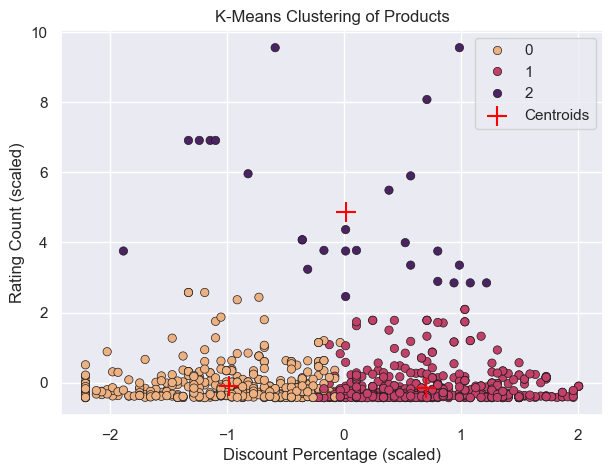

In [71]:
import seaborn as sns

plt.figure(figsize=(7,5))
sns.scatterplot(
    x=X_train[:, 0],   # discount_percentage (scaled)
    y=X_train[:, 3],   # rating_count (scaled)
    hue=labels_train,
    palette="flare",
    edgecolor="k"
)

plt.scatter(
    k_means.cluster_centers_[:, 0],
    k_means.cluster_centers_[:, 3],
    c="red",
    marker="+",
    s=200,
    label="Centroids"
)

plt.title("K-Means Clustering of Products")
plt.xlabel("Discount Percentage (scaled)")
plt.ylabel("Rating Count (scaled)")
plt.legend(bbox_to_anchor=(1,1))
plt.show()

This visualization displays products grouped into three distinct clusters based on standardized discount percentage and rating count. The clusters separate products with low discounts and low engagement, moderate discounts with high popularity, and higher discounts with mixed engagement, while the red centroids represent the typical profile of each group. This confirms that discount level and popularity together form meaningful product segments.

In [73]:
amazon["cluster"] = np.nan
amazon.loc[features_clean.index, "cluster"] = labels

In [75]:
amazon.groupby("cluster")[[
    "discount_percentage",
    "discount_depth",
    "rating",
    "rating_count"
]].mean()

,discount_percentage,discount_depth,rating,rating_count
cluster,,,,
0.0,63.109741,0.631087,4.041677,12020.102343
1.0,27.129870,0.271233,4.163961,13927.626623
2.0,51.514286,0.514051,4.188571,241076.114286


The table summarizes the average characteristics of each cluster, highlighting clear behavioral differences. One cluster is characterized by high discounts and very high review counts, another by moderate discounts and stable ratings, and a third by lower discounts and lower engagement. These patterns show that discounts mainly differentiate products by popularity rather than satisfaction, reinforcing earlier regression and visualization results (more detailed I added in the report).

**A/B testing**

In [77]:
median_discount = amazon["discount_percentage"].median()

amazon["ab_group"] = np.where(
    amazon["discount_percentage"] <= median_discount,
    "A_Low_Discount",
    "B_High_Discount"
)

amazon["ab_group"].value_counts()

ab_group
A_Low_Discount     770
B_High_Discount    693
Name: count, dtype: int64

Products were split into two groups based on the median discount level: low discounts (Group A) and high discounts (Group B), allowing a direct comparison of customer behavior across pricing strategies.

In [79]:
amazon.groupby("ab_group")[["rating", "rating_count"]].mean()

,rating,rating_count
ab_group,,
A_Low_Discount,4.127048,17748.003896
B_High_Discount,4.063059,18903.916306


Low-discount products have slightly higher average ratings, while high-discount products attract more reviews, indicating higher engagement but lower perceived quality.

In [81]:
from scipy.stats import ttest_ind

group_A = amazon[amazon["ab_group"] == "A_Low_Discount"]
group_B = amazon[amazon["ab_group"] == "B_High_Discount"]
t_pop, p_pop = ttest_ind(
    group_A["rating_count"],
    group_B["rating_count"],
    equal_var=False,
    nan_policy="omit"
)
t_rate, p_rate = ttest_ind(
    group_A["rating"],
    group_B["rating"],
    equal_var=False,
    nan_policy="omit"
)
t_pop, p_pop, t_rate, p_rate

(-0.5107218561225673,
 0.6096302250008385,
 4.214820359775128,
 2.6620121753262284e-05)

Higher discounts increase customer attention but do not improve satisfaction, suggesting diminishing returns from aggressive discounting (more detailed in the report)